# tap.garden~ — the garden, measured

The generative event loop (`taptools/garden.h`), a recreation of the *principle* behind
Eno/Chilvers' Bloom: a planted note snaps to the scale, blooms on a two-operator FM bell,
and returns every loop pass a step quieter (`decay`) and purer (`soften`) until it retires
below the `floor`; left idle, a seeded gardener plants for you. The family's stability
inversion, one level up: **per-pass decay is the stabilizer** — the event population
converges by construction, and a fixed sixteen-bell pool hard-bounds the audio. Every trace
drives the **shipping C++** through `tools/capi` via ctypes.

Sections: **1** the return staircase · **2** softening, in partials · **3** the scale
contract, by the pitch oracle · **4** the seeded gardener · **5** an hour of garden,
in two minutes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
sr = 48000.0

def tone(x, f):
    n = np.arange(x.size)
    return 2.0 * np.abs(np.dot(x, np.exp(-2j * np.pi * f * n / sr))) / x.size

## 1 · The return staircase

One note planted at velocity 0.8 into a 0.5 s loop, `decay` 0.5, `floor` 0.05: the bloom
returns at 0.8, 0.4, 0.2, 0.1, 0.05 — a measured staircase of halvings — and then retires;
`active_events` drops to zero and the garden is silent. That retirement arithmetic
(`ceil(log(floor/velocity)/log(decay))` passes, always) is the population-convergence
theorem in one plant. (Kernel scenarios: *"a planted note blooms again every loop period"*,
*"each return is quieter by the decay ratio and the bloom retires below the floor"*.)

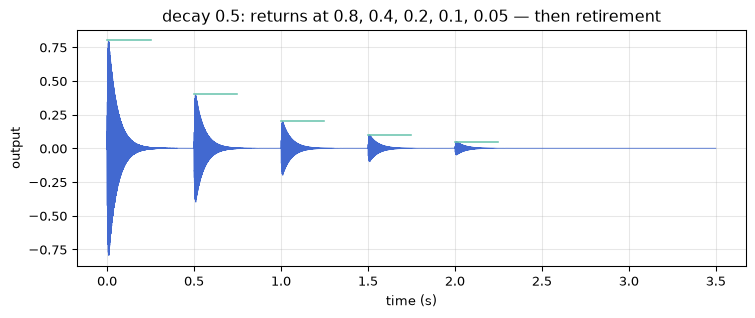

per-return peaks: [np.float64(0.795), np.float64(0.399), np.float64(0.2), np.float64(0.1), np.float64(0.05), np.float64(0.0)]
live events after the render: 0


In [2]:
g = tap.Garden(sr, smooth_ms=0, idle_seconds=0, loop_seconds=0.5,
               decay=0.5, floor=0.05, bell=(0.002, 0.05, 1.0), scale=0)
g.note(69, 0.8)
y = g.process(int(3.5 * sr))

t = np.arange(y.size) / sr
fig, ax = plt.subplots()
ax.plot(t, y, color=C[0], lw=0.6)
for k, v in enumerate([0.8 * 0.5 ** i for i in range(5)]):
    ax.plot([k * 0.5, k * 0.5 + 0.25], [v, v], color=C[3], lw=1.2)
ax.set_xlabel("time (s)"); ax.set_ylabel("output")
ax.set_title("decay 0.5: returns at 0.8, 0.4, 0.2, 0.1, 0.05 — then retirement")
plt.show()

peaks = [np.abs(y[int(k * 0.5 * sr) : int((k + 1) * 0.5 * sr)]).max() for k in range(6)]
print("per-return peaks:", [round(p, 3) for p in peaks])
print("live events after the render:", g.active_events)

## 2 · Softening, in partials

With `decay` held at 1.0 (velocity still) and `soften` 0.6, only the timbre moves: the FM
bell's first upper sideband (4× the fundamental, carrier + ratio-3 modulator) fades pass by
pass while the fundamental holds — each return is *purer*, collapsing toward a sine. The
tape family's generation loss, restated in partials instead of passbands.

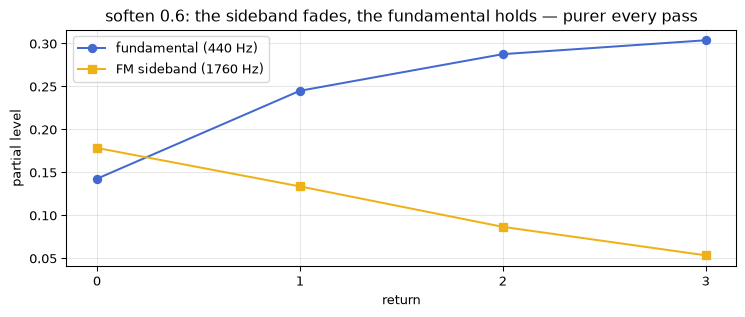

sideband/fundamental per return: [np.float64(1.252), np.float64(0.546), np.float64(0.301), np.float64(0.175)]


In [3]:
g = tap.Garden(sr, smooth_ms=0, idle_seconds=0, loop_seconds=0.5,
               decay=1.0, floor=0.001, soften=0.6, bell=(0.005, 0.06, 1.0), scale=0)
g.note(69, 0.8)  # 440 Hz carrier -> first upper sideband at 1760 Hz
y = g.process(int(2.5 * sr))

loop = int(0.5 * sr)
passes = np.arange(4)
fund = [tone(y[k * loop : k * loop + int(0.2 * sr)], 440.0) for k in passes]
side = [tone(y[k * loop : k * loop + int(0.2 * sr)], 1760.0) for k in passes]

fig, ax = plt.subplots()
ax.plot(passes, fund, "o-", color=C[0], label="fundamental (440 Hz)")
ax.plot(passes, side, "s-", color=C[1], label="FM sideband (1760 Hz)")
ax.set_xticks(passes)
ax.set_xlabel("return"); ax.set_ylabel("partial level")
ax.set_title("soften 0.6: the sideband fades, the fundamental holds — purer every pass")
ax.legend()
plt.show()

print("sideband/fundamental per return:",
      [round(s / f, 3) for s, f in zip(side, fund)])

## 3 · The scale contract, by the pitch oracle

Plant every chromatic pitch from 60 to 72 into a C major-pentatonic garden and measure what
actually sounds with the DspTap YIN detector: every bloom lands on {C, D, E, G, A}, whatever
you planted. Quantization happens at entry — the instrument makes wrong notes impossible,
which is most of why Bloom-style instruments feel effortless. (Kernel scenario: *"every
bloom lands on the scale"*.)

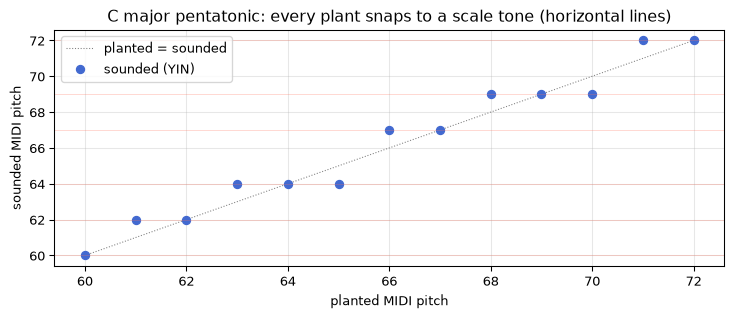

all sounded pitches on the scale: True


In [4]:
pent = {0, 2, 4, 7, 9}
planted = np.arange(60, 73)
sounded = []
for p in planted:
    g = tap.Garden(sr, smooth_ms=0, idle_seconds=0, loop_seconds=2.0,
                   scale=3, root=0, bell=(0.01, 0.5, 0.4))
    g.note(float(p), 0.8)
    y = g.process(int(0.5 * sr))
    periods = tap.Yin().track(y[int(0.1 * sr):], hop=512)
    hz = sr / np.median(periods[periods > 0])
    sounded.append(69 + 12 * np.log2(hz / 440.0))

fig, ax = plt.subplots()
ax.plot(planted, planted, ":", color="gray", lw=0.8, label="planted = sounded")
ax.plot(planted, sounded, "o", color=C[0], label="sounded (YIN)")
for m in range(60, 73):
    if m % 12 in pent:
        ax.axhline(m, color=C[2], lw=0.5, alpha=0.4)
ax.set_xlabel("planted MIDI pitch"); ax.set_ylabel("sounded MIDI pitch")
ax.set_title("C major pentatonic: every plant snaps to a scale tone (horizontal lines)")
ax.legend()
plt.show()

ok = all(round(s) % 12 in pent for s in sounded)
print("all sounded pitches on the scale:", ok)

## 4 · The seeded gardener

Idle for half a second, then the garden plays itself: roughly one plant per loop pass,
uniformly placed, on the scale, within two octaves. The randomness rides the family's
seeded xorshift64* — same seed, bit-identical garden; different seed, different garden;
gardener disabled, the seed cannot matter at all (the rng is never consumed). The library's
first randomized event source, with the tr808 seed triad as its contract.

same seed bit-exact: True   different seed differs: True


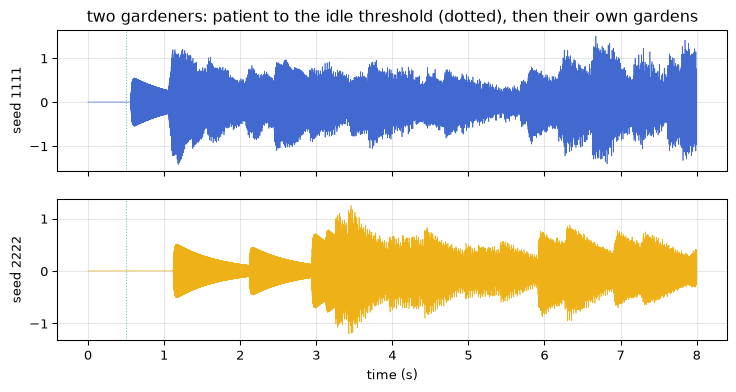

In [5]:
def render_idle(seed, seconds=8.0):
    g = tap.Garden(sr, smooth_ms=0, idle_seconds=0.5, loop_seconds=1.0,
                   seed=seed, bell=(0.01, 0.6, 0.8), decay=0.7)
    return g.process(int(seconds * sr))

a = render_idle(1111)
b = render_idle(1111)
c = render_idle(2222)
print("same seed bit-exact:", bool(np.all(a == b)),
      "  different seed differs:", bool(np.any(a != c)))

t = np.arange(a.size) / sr
fig, axes = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True)
for ax, y, seed, color in [(axes[0], a, 1111, C[0]), (axes[1], c, 2222, C[1])]:
    ax.plot(t, y, color=color, lw=0.5)
    ax.axvline(0.5, color=C[3], ls=":", lw=0.8)
    ax.set_ylabel(f"seed {seed}")
axes[1].set_xlabel("time (s)")
axes[0].set_title("two gardeners: patient to the idle threshold (dotted), then their own gardens")
plt.show()

## 5 · An hour of garden, in two minutes

A handful of hand-planted notes to start, then the gardener takes over: `decay` 0.85 and
`soften` 0.9 keep each bloom returning for a dozen passes, softening as it goes; the
population breathes around its converged size instead of piling up. This render would go on
— unrepeating, bounded, self-tending — for exactly as long as you let it.

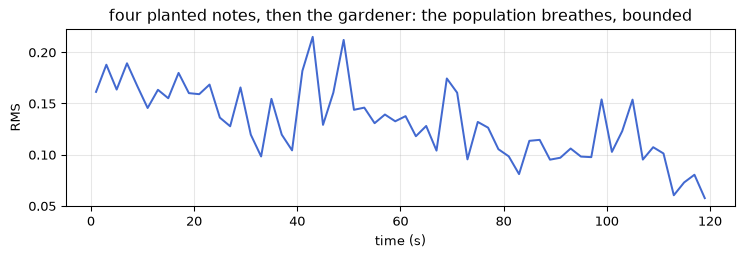

live events at the end: 20  ringing bells: 16


In [6]:
from IPython.display import Audio

g = tap.Garden(sr, smooth_ms=0, loop_seconds=6.0, decay=0.85, soften=0.9, floor=0.02,
               bell=(0.12, 3.0, 0.9), scale=3, root=9, idle_seconds=4.0, seed=2008,
               level=0.35)

chunks = []
plants = [(0.0, 69, 0.7), (1.2, 76, 0.55), (2.6, 64, 0.6), (4.0, 81, 0.4)]
cursor = 0.0
for when, pitch, vel in plants:
    n = int((when - cursor) * sr)
    if n > 0:
        chunks.append(g.process(n))
    g.note(pitch, vel)
    cursor = when
chunks.append(g.process(int((120.0 - cursor) * sr)))
y = np.concatenate(chunks)

win = int(2.0 * sr)
frames = y[: y.size // win * win].reshape(-1, win)
fig, ax = plt.subplots(figsize=(9, 2.4))
ax.plot((np.arange(frames.shape[0]) + 0.5) * 2.0, np.sqrt((frames ** 2).mean(axis=1)),
        color=C[0])
ax.set_xlabel("time (s)"); ax.set_ylabel("RMS")
ax.set_title("four planted notes, then the gardener: the population breathes, bounded")
plt.show()
print("live events at the end:", g.active_events, " ringing bells:", g.active_voices)

# Preview: first 60 s, embedded at 16 kHz to keep the executed notebook small (the bells
# live below 4 kHz); tools/render writes the full-rate, full-length WAVs.
Audio(np.clip(y[: int(60 * sr) : 3], -1, 1), rate=int(sr / 3))